# Email Spam Detection
We’ve all been the recipient of spam emails before. Spam mail, or junk mail, is a type of email
that is sent to a massive number of users at one time, frequently containing cryptic
messages, scams, or most dangerously, phishing content.


In this Project, use Python to build an email spam detector. Then, use machine learning to
train the spam detector to recognize and classify emails into spam and non-spam. Let’s get
started!

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import string
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### 2. Load Data

In [2]:
# Read CSV, ignoring encoding errors
df = pd.read_csv('dataset.csv', encoding='latin-1')

# The dataset usually contains 'v1' (label) and 'v2' (message) along with some empty columns.
df = df[['v1', 'v2']]

# Rename columns → label, message
df.rename(columns={'v1': 'label', 'v2': 'message'}, inplace=True)
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### 3. Data Cleaning
Convert text to lowercase, remove punctuation, and remove stopwords.

In [3]:
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])
    # Remove stopwords
    text = ' '.join([word for word in text.split() if word not in ENGLISH_STOP_WORDS])
    return text

# Apply data cleaning
df['message'] = df['message'].apply(clean_text)

# Map labels to numerical values (ham=0, spam=1)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,message
0,0,jurong point crazy available bugis n great wor...
1,0,ok lar joking wif u oni
2,1,free entry 2 wkly comp win fa cup final tkts 2...
3,0,u dun say early hor u c say
4,0,nah dont think goes usf lives


### 4. Convert Text → Numbers
Use TF-IDF Vectorizer

In [4]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['message'])
y = df['label']

### 5. Train Model
Using Naive Bayes (best for spam detection)

In [5]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Naive Bayes model
model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


### 6. Evaluate
Accuracy score and Confusion matrix

In [6]:
y_pred = model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 96.77%

Confusion Matrix:
[[965   0]
 [ 36 114]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.76      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



### 7. Show Output
Print accuracy and show prediction examples

In [7]:
# Print accuracy again as requested
print(f"Final Model Accuracy: {accuracy * 100:.2f}%")

# Show prediction examples
example_messages = [
    "Congratulations! You've won a $1,000 gift card. Click here to claim.",
    "Hey, are we still meeting for lunch at 1 PM?",
    "URGENT: Your account has been compromised. Update your details immediately.",
    "Can you send me the report by EOD?"
]

# Clean and predict the examples
example_cleaned = [clean_text(msg) for msg in example_messages]
example_features = vectorizer.transform(example_cleaned)
predictions = model.predict(example_features)

print("\nPrediction Examples:")
for msg, pred in zip(example_messages, predictions):
    label = "Spam" if pred == 1 else "Ham (Not Spam)"
    print(f"- '{msg}' \n  \u2192 Prediction: {label}\n")

Final Model Accuracy: 96.77%

Prediction Examples:
- 'Congratulations! You've won a $1,000 gift card. Click here to claim.' 
  → Prediction: Spam

- 'Hey, are we still meeting for lunch at 1 PM?' 
  → Prediction: Ham (Not Spam)

- 'URGENT: Your account has been compromised. Update your details immediately.' 
  → Prediction: Ham (Not Spam)

- 'Can you send me the report by EOD?' 
  → Prediction: Ham (Not Spam)



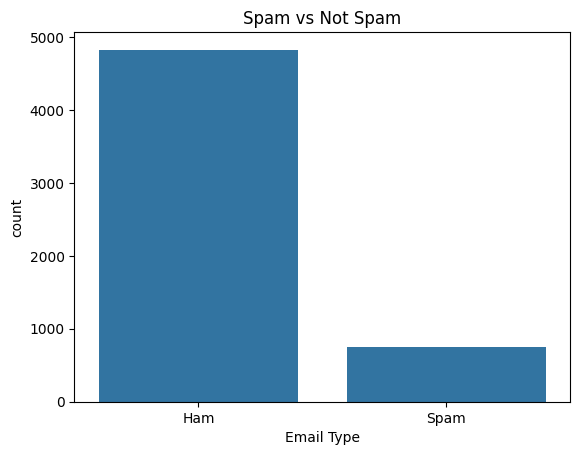

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['label'])
plt.title("Spam vs Not Spam")
plt.xticks(ticks=[0, 1], labels=['Ham', 'Spam'])
plt.xlabel("Email Type")
plt.show()